### Tarea Examen 2

Nombre: **Lara Cruz Karla Verónica**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

1.- Se tiene un oscilador armónico en dos dimensiones, es decir en el plano \$(xy)\$ y en el que la fuerza está dada por $\vec{F}=-k\vec{r}$. Además se tiene una fricción $\vec{f}_{fric}=-\gamma \vec{v}$ si $|\vec{v}|\leq 1$, pero cuando $|\vec{v}|> 1$ la fricción es $\vec{f}_{fric}=-\mu v^2\hat{v}$. Si $m=1$, $k=1$, $\gamma = 0.15$ y $\mu = 0.25$, resuelva los siguientes ejercicios:

    (a) Encuentre las ecuaciones de movimiento en coordenadas cartesianas. No es necesario resolver las ecuaciones. 


En coordenadas cartesianas tenemos que $\vec{r}=(x,y)$, $\vec{v}=(\dot{x},\dot{y})$, $\vec{a}=(\ddot{x},\ddot{y})$, $v=(\dot{x}^2+\dot{y}^2)^{1/2}$ y $\hat{v}=\frac{\vec{v}}{v}$.

Si $|\vec{v}|\leq 1$:
<ul>
<li> $\ddot{x} = -x-0.15\dot{x}$ </li>
<li>$\ddot{y} = -y-0.15\dot{y}$</li>
</ul>

Si $|\vec{v}|> 1$:
<ul>
<li> $\ddot{x} = -x-0.25v\dot{x}$ </li>
<li>$\ddot{y} = -y-0.25v\dot{y}$</li>
</ul>

(b) Utilice el método de Runge-Kutta de 4to orden para encontrar la solución a las ecuaciones de movimiento en el inciso anterior con condiciones iniciales $\vec{r}_0=(0,1)$ y $\vec{v}_0 =(2\cos{\theta},2\sin{\theta})$, donde $\theta = (n\pi)/6$ con $n=0,1,2,...,10,11.$

In [25]:
def RK4(g,x0,t):
    h = t[1]-t[0]
    sol = np.zeros( (len(x0) , len(t)) )
    sol[:,0] = x0
    for i in range(len(t)-1):
        k1 = g(sol[:,i],t[i])
        k2 = g(sol[:,i] + 0.5*h*k1 , t[i] + 0.5*h)
        k3 = g(sol[:,i] + 0.5*h*k2 , t[i] + 0.5*h)
        k4 = g(sol[:,i] + h*k3 , t[i] + h)
        sol[:,i+1] = sol[:,i] + (h/6.0)*(k1 + 2.0*k2 + 2.0*k3 + k4)
    return sol

In [26]:
#Definimos mi función g

def g(r_v,t):
    v = np.sqrt((r_v[2])**2 + (r_v[3])**2)
    g1 = r_v[2]   #Obtenida de nuestro cambio de variable x'=v_x
    g2 = r_v[3]   #Obtenida de nuestro cambio de variable y'=v_y
    if v <= 1:
        g3 = -r_v[0] - 0.15*r_v[2]
            #Obtenida al sustituir x'=v_x en nuestra ec. dif. original
        g4 = -r_v[1] - 0.15*r_v[3]
            #Obtenida al sustituir y'=v_y en nuestra ec. dif. original
    else:
        g3 = -r_v[0] - 0.25*v*r_v[2]
        g4 = -r_v[1] - 0.25*v*r_v[3]
    
    return np.array([g1,g2,g3,g4])
        

In [27]:
n = np.arange(0,12,1)
t = np.linspace(0,20,380)
a = []
r_v = [0,1,0,0]

for i in n:
    theta = (i*np.pi)/6
    r_v[2] = 2*np.cos(theta)
    r_v[3] = 2*np.sin(theta)
    sol = RK4(g,r_v,t)
    a.append(sol)
arreglo = np.array(a)


    (c) Genere una función que calcule la energía para las distintas condiciones iniciales y detenga la simulación cuando esta sea menor al 30% de su valor inicial. Cabe mencionar que debe hacer su simulación (paso de inegración) de tal manera que el error en la trayectoria no tenga variaciones de más del 0.1% a la trayectoria que debería tener, es decir se debe asegurar convergencia en la solución con error reslativo de a lo más 0.1%.

In [28]:
for i in range(len(t)):                  #Usado para encontrar la h indicada (si teníamos de salida i,a repetíamos el proceso dis-
    a = np.abs(arreglo[0,0,i]-arreglo[0,0,i*2])   #minuyendo h1 una unidad). Encontramos que el paso que
    if a >= 0.0001:
        print(i,a)
        break

1 0.10119829432986764


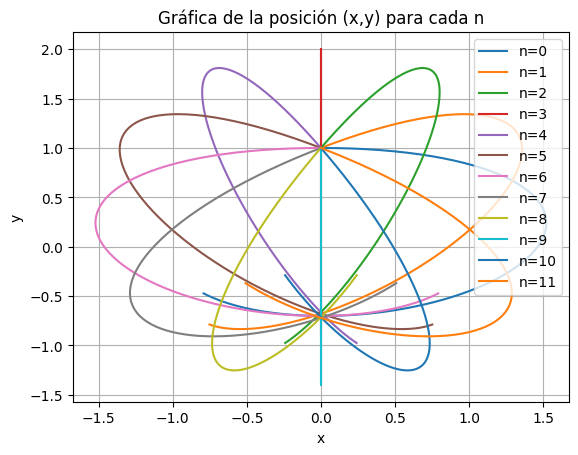

In [29]:
#Sabemos que T = (1/2)mv^2 = (1/2)m(x'^2 + y'^2). Además, consideraremos el potencial elástico como el unic involucrado; por lo
# que, V = (1/2)kr^2 = (1/2)k(x^2 + y^2).

for i in range(len(n)):
    ejex = []
    ejey = []
    m = (0.5*((arreglo[i,0,0])**2 + (arreglo[i,1,0])**2 + (arreglo[i,2,0])**2 + (arreglo[i,3,0])**2))*0.3 
        #Saca el 30% de la energía inicial en cada n
    for j in range(len(t)):
        E = 0.5*((arreglo[i,0,j])**2 + (arreglo[i,1,j])**2 + (arreglo[i,2,j])**2 + (arreglo[i,3,j])**2)
        ejex.append(arreglo[i,0,j])
        ejey.append(arreglo[i,1,j])
        if E < m:
               break

    plt.plot(ejex,ejey, label=f'n={i}')
plt.title('Gráfica de la posición (x,y) para cada n')
plt.legend()
plt.xlabel('x'),plt.ylabel('y')
plt.grid()
plt.show()


    (d) Dibuje las gráficas del momento angular para los casos del inciso (1b).

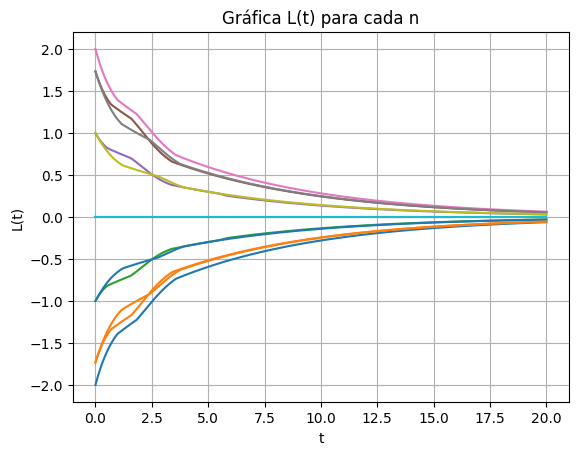

In [30]:
#Sabemos que L=rxp=(xp_y - yp_x)(z_unitario) por lo que |L|=(xp_y - yp_x)
for i in range(len(n)):
    L_n = []
    for j in range(len(t)):
        L = ((arreglo[i,0,j])*(arreglo[i,3,j]) - (arreglo[i,1,j])*(arreglo[i,2,j]))
        L_n.append(L)

    plt.plot(t,L_n, label=f'n={i}')


plt.title('Gráfica L(t) para cada n')
plt.xlabel('t'),plt.ylabel('L(t)')
plt.grid()
plt.show()

    (e) Tome de manera arbitraria alguna condición inicial y dibuje el espacio fase

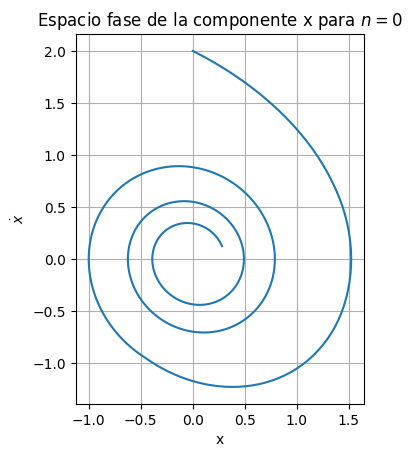

In [31]:
#Sea n=0
plt.plot(arreglo[0,0,:],arreglo[0,2,:])
plt.title(r'Espacio fase de la componente x para $n=0$')
plt.xlabel('x'),plt.ylabel(r'$\dot{x}$')
plt.gca().set_aspect("equal")
plt.grid()
plt.show()

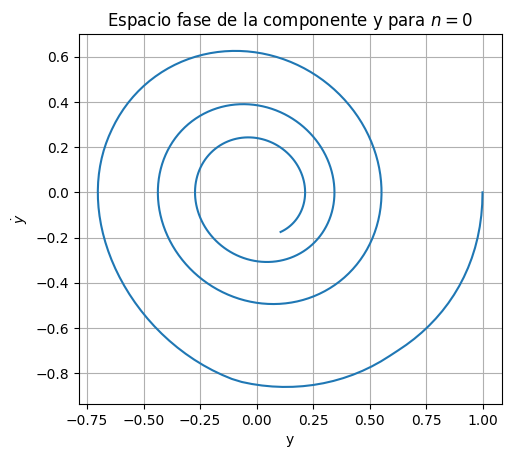

In [32]:
plt.plot(arreglo[0,1,:],arreglo[0,3,:])
plt.title(r'Espacio fase de la componente y para $n=0$')
plt.xlabel('y'),plt.ylabel(r'$\dot{y}$')
plt.gca().set_aspect("equal")
plt.grid()
plt.show()

--------------------

2.- Suponga que se tienen dos partículas de masa $m$ y que una de ellas se encuentra anclada al origen. La fuerza entre ellas es de tipo resorte dada por $\vec{F}=-k\vec{r}$. Además, ambas partículas tienen carga $q>0$ por lo que también pueden interactuar por fuerza de Coulomb.

    (a) Sin considerar la fricción, ¿El sistema puede tener órbitas cerradas?. De ser así, encuentre algunas de estas órbitas o muestre que el sistema no puede tener este tipo de órbitas. (Apoye sus argumentos con algunas simulaciones).

In [42]:
#Sí se pueden tener órbitas cerradas. Tenemos una de las partículas anclada al origen (1), por lo que la cinemática del sistema se
# centra en el movimiento de la otra partícula (2) que queda libre y se ve afectada por 1. 
# Restringiéndonos a 2 dimensiones. La fuerza tipo resorte (F1) entre las partículas hace que (2) gire alrededor de (1) siguiendo una 
# trayectoria cerrada elíptica. Por otra parte, la fuerza de coulomb (F2) lo que trata constantemente es separar a las partículas, 
# pero es en esta parte donde es importante recordar la forma de F1; va en dirección contraria a la posición, por lo que entre más 
# aleje F2 a (2) de (1), F1 tratará de acercar a (2). De acuerdo con el teorema de Bertrand que haya trayectorias cerradas es un 
# caso específico, en general lo que hace el sistema es trazar elipses que van rotando; hay precesión

# Para la simulación tomamos la ec diferencial en cartesianas que se obtiene de ma = F = F1 + F2 considerando m=k=q=1
def p2(r_v,t):
    r = (np.sqrt((r_v[0])**2 + (r_v[1])**2))**3
    g1 = r_v[2]   #Obtenida de nuestro cambio de variable x'=v_x
    g2 = r_v[3]   #Obtenida de nuestro cambio de variable y'=v_y

    g3 = -r_v[0] + (20/r)*r_v[0]
        #Obtenida al sustituir x'=v_x en nuestra ec. dif. original
    g4 = -r_v[1] + (20/r)*r_v[1]
        #Obtenida al sustituir y'=v_y en nuestra ec. dif. original
    return np.array([g1,g2,g3,g4])
        

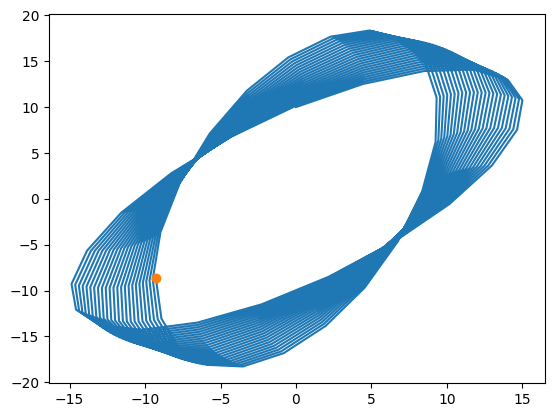

In [43]:
t = np.linspace(0,150,500)
r_v = [0,10,15,10]

sol = RK4(p2,r_v,t)
plt.plot(sol[0,:],sol[1,:])
plt.plot(sol[0,-1],sol[1,-1],'o')
plt.show()

    (b) Considerando fricción proporcional a la velocidad, ¿El sistema puede tener órbitas cerradas?. De ser así, encuentre algunas de estas órbitas o muestre que el sistema no puede tener este tipo de órbitas. (Apoye sus argumentos con algunas simulaciones).

In [44]:
#No, las órbitas se van haciendo más pequeñas conforme el paso del tiempo hasta que la partícula llegue a v=0 en
def p2_fric(r_v,t):
    r = (np.sqrt((r_v[0])**2 + (r_v[1])**2))**3
    v = np.sqrt((r_v[2])**2 + (r_v[3])**2)
    g1 = r_v[2]   #Obtenida de nuestro cambio de variable x'=v_x
    g2 = r_v[3]   #Obtenida de nuestro cambio de variable y'=v_y

    g3 = -r_v[0] + (2/r)*r_v[0] - 0.15*v*r_v[2]
        #Obtenida al sustituir x'=v_x en nuestra ec. dif. original
    g4 = -r_v[1] + (2/r)*r_v[1] - 0.15*v*r_v[3]
        #Obtenida al sustituir y'=v_y en nuestra ec. dif. original
    return np.array([g1,g2,g3,g4])
        

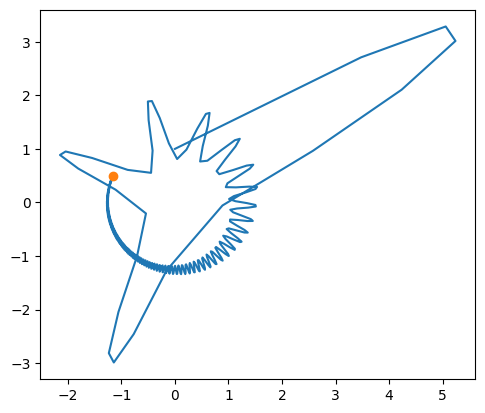

In [45]:
t = np.linspace(0,400,800)
r_v = [0,1,10,5]

sol = RK4(p2_fric,r_v,t)
plt.plot(sol[0,:],sol[1,:])
plt.plot(sol[0,-1],sol[1,-1],'o')
plt.gca().set_aspect("equal")
plt.show()

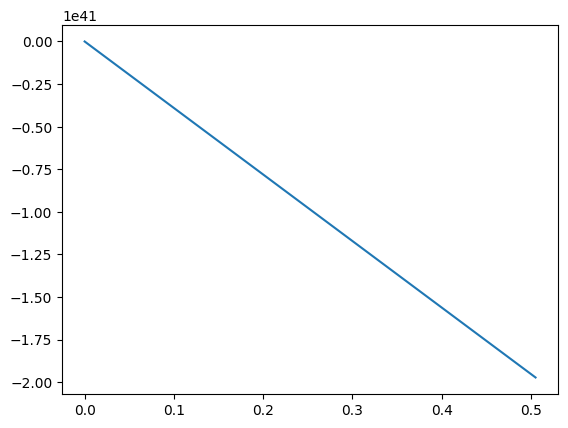

In [50]:
#Podemos ver que la velocidad tiende a 0, es decir va a perder energía hasta quedarse suspendido en una posición de equilibrio.
plt.plot(t,sol[3,:])
plt.plot(t[0],sol[1,-1],'o')
plt.show()

-------------

3.- Considere el sistema Tierra y Luna. Tome en cuenta sus dimensiones reales de masa, tamaño y movimiento relativo. Con la finalidad de simplificar el problema, considere que la Luna está en una órbita casi circular de acuerdo con la mecánica de Newton. Ahora considere un satélite artificial de 35 toneladas que sale de la superficie de la Tierra hacia la Luna. Encuentre una treyectoria que salga de la Tierra, de la vuelta a la Luna, y regrese a la Tierra (la treyectoria debe parecer un "ocho"), y realice una animación de la trayectoria para mostrar el resultado. Si consideramos que inicialmente la Tierra y la Luna están sobre el plano $xy$ y que además están sobre el eje $x$. ¿Cuál es la condición inicial que debe tener el satélite artificial para describir dicha trayectoria?

In [47]:
#Si no consideramos la fuerza de atracción gravitacional entre la Luna y la Tierra, las fuerzas que experimenta el satélite son 
# debido a su atracción con la Tierra (FT) y la Luna (FL). De acuerdo con el problema fijamo a la Tierra como el centro de nuestro
# sistema de referencia; para FT tenemos:
#          FT = G(mT)(ms)(x,y)/(r)^3
# Donde r tiene que considerar que parte desde la superficie de la Tierra; r = r - radio_de_la_Tierra
# Respeto a FL, desde el sistema de referencia de la Luna:
#          FL = G(mL)(ms)(x',y')/(r')^3
# Sea R un vector que va desde el centro de la Tierra a la Luna;
#          (x',y') = (x,y) - (Rx,Ry)
# Donde Rx = Rcos(wt), Rx = Rsen(wt), w corresponde a la velocidad angular promedio de la luna respecto a la Tierra


#Definimos la función para la trayectoria del satélite:
def S(r_v,t):
    G = 6.7*(10**(-4))
    mT = 5.972*(10**(24))
    mL = 7.35*(10**(22))
    R = 384400
    w = 2.66*(10**(-6))
    r = np.sqrt( r_v[0]**2 + r_v[1]**2 )
    rr = np.sqrt( (r_v[0] - R*np.cos(w*t))**2  +  (r_v[1] - R*np.sin(w*t))**2 )     # r medida desde el sistema luna
    
    g1 = r_v[2]   #Obtenida de nuestro cambio de variable dx/dt=v_x
    g2 = r_v[3]   #Obtenida de nuestro cambio de variable dy/dt=v_y

    g3 = (G*mT*r_v[0])/(r**3)  +  (G*mL*( r_v[0] - (R*np.cos(w*t)) ))/(rr**3)
    g4 = (G*mT*r_v[1])/(r**3)  +  (G*mL*( r_v[1] - (R*np.sin(w*t)) ))/(rr**3)
    
    return np.array([g1,g2,g3,g4])

C:\Users\karla\AppData\Local\Temp\ipykernel_28692\3416428360.py:4: RuntimeWarning: overflow encountered in scalar power
  v = np.sqrt((r_v[2])**2 + (r_v[3])**2)
C:\Users\karla\AppData\Local\Temp\ipykernel_28692\3416428360.py:3: RuntimeWarning: overflow encountered in scalar power
  r = (np.sqrt((r_v[0])**2 + (r_v[1])**2))**3
C:\Users\karla\AppData\Local\Temp\ipykernel_28692\1400482217.py:10: RuntimeWarning: invalid value encountered in add
  sol[:,i+1] = sol[:,i] + (h/6.0)*(k1 + 2.0*k2 + 2.0*k3 + k4)
C:\Users\karla\AppData\Local\Temp\ipykernel_28692\3416428360.py:8: RuntimeWarning: invalid value encountered in scalar multiply
  g3 = -r_v[0] + (2/r)*r_v[0] - 0.15*v*r_v[2]
C:\Users\karla\AppData\Local\Temp\ipykernel_28692\3416428360.py:10: RuntimeWarning: invalid value encountered in scalar multiply
  g4 = -r_v[1] + (2/r)*r_v[1] - 0.15*v*r_v[3]


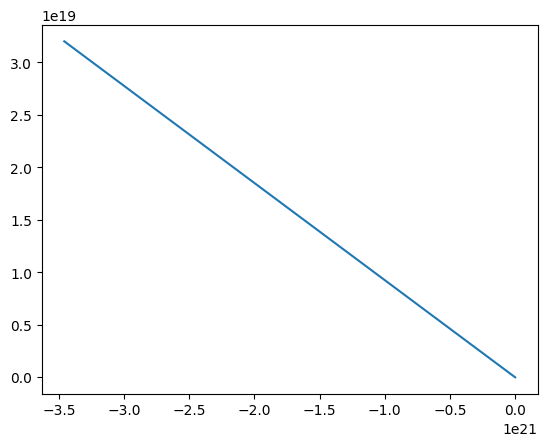

In [49]:
t = np.linspace(0,50,100)
r_v = [6371,0,10800,-100] #No pude encontrar las condiciones iniciales neesarias :c

sol = RK4(p2_fric,r_v,t)
plt.plot(sol[0,:],sol[1,:])
plt.plot(sol[0,-1],sol[1,-1],'o')
plt.show()

---------------